# Luggage Email/Outbound — EDA

Exploratory analysis of all luggage weight variant (L5B15/L5B20/L5B25/L5B30/L5B40/L5B50/CLUG)
Email/Outbound/Luggage/Sales scoring events.
Reads from `data/processed/luggage_email_outbound.parquet` — run `02_data_ingestion.ipynb` first.

In [ ]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Imports OK")

In [ ]:
PROCESSED_FILE = Path("../data/processed/luggage_email_outbound.parquet")
df_model = pd.read_parquet(PROCESSED_FILE)
print(f"Loaded {len(df_model):,} rows, {df_model.shape[1]} columns")
print("pyName breakdown:")
print(df_model["pyName"].value_counts().to_string())
df_model.head(3)

## Temporal Distribution

When were these decisions made? Uses  — the actual Pega interaction timestamp.

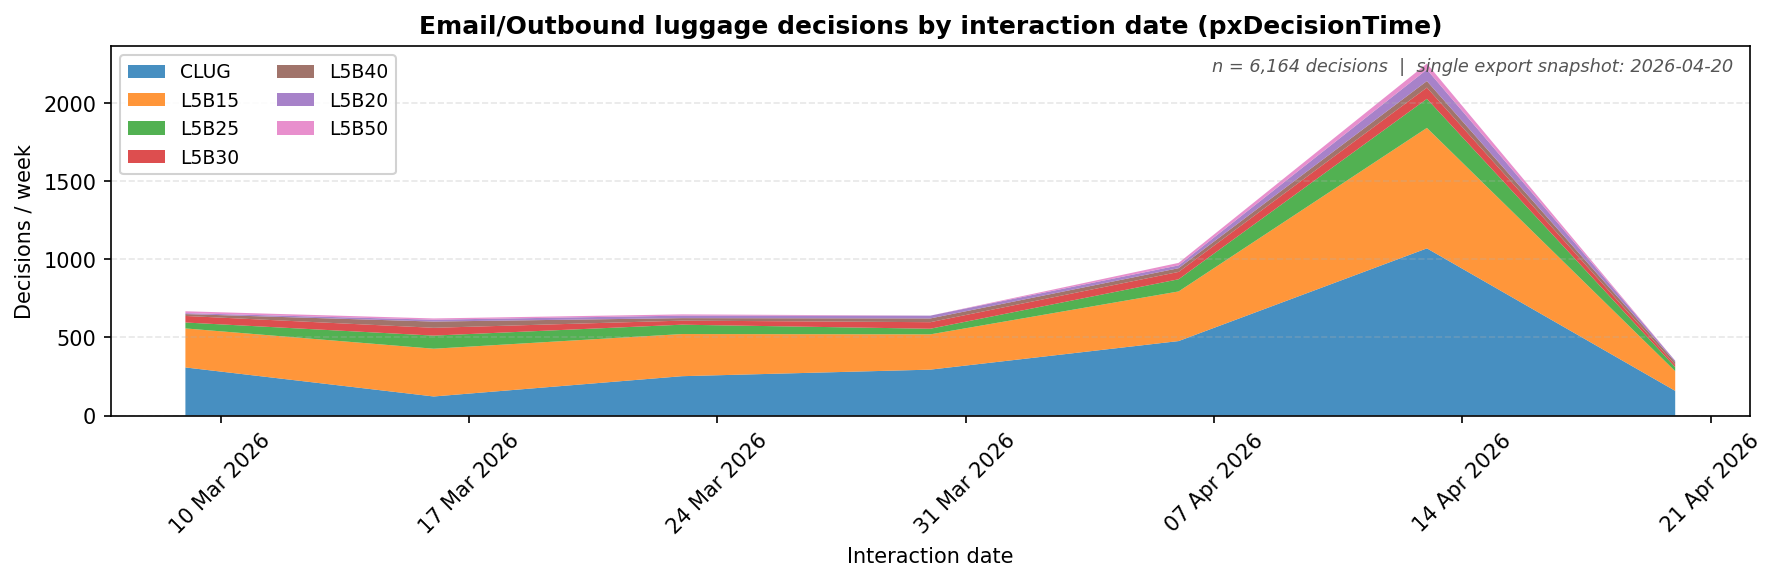

In [1]:
import matplotlib.dates as mdates

COLORS = {
    "CLUG":  "#1f77b4",
    "L5B15": "#ff7f0e",
    "L5B25": "#2ca02c",
    "L5B30": "#d62728",
    "L5B20": "#9467bd",
    "L5B40": "#8c564b",
    "L5B50": "#e377c2",
}

# Parse decision time if not already datetime
if df_model["pxDecisionTime"].dtype == "object":
    dt_col = pd.to_datetime(
        df_model["pxDecisionTime"], format="%Y%m%dT%H%M%S.%f %Z", utc=True, errors="coerce"
    )
else:
    dt_col = df_model["pxDecisionTime"]

df_t = df_model.copy()
df_t["week"] = dt_col.dt.to_period("W").dt.start_time

has_time = df_t["week"].notna().sum()
print(f"{has_time:,} of {len(df_t):,} rows have a valid pxDecisionTime")

pv = (
    df_t.dropna(subset=["week"])
    .groupby(["week", "pyName"]).size()
    .reset_index(name="count")
    .pivot(index="week", columns="pyName", values="count")
    .fillna(0)
)
col_order = pv.sum().sort_values(ascending=False).index.tolist()
pv = pv[col_order]

fig, ax = plt.subplots(figsize=(13, 4))
ax.stackplot(
    pv.index,
    [pv[c] for c in col_order],
    labels=col_order,
    colors=[COLORS.get(c, "#aaa") for c in col_order],
    alpha=0.82,
)
ax.set_title("Email/Outbound luggage decisions by interaction date (weekly)", fontsize=12, fontweight="bold")
ax.set_ylabel("Decisions / week")
ax.set_xlabel("Interaction date (pxDecisionTime)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="upper left", fontsize=9, framealpha=0.88, ncol=2)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.text(0.99, 0.97, f"n = {has_time:,} decisions",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#333")

plt.tight_layout()
plt.savefig("../data/luggage_decisions_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Data Quality Assessment

Assess missingness, constant columns, target distribution, feature correlations, and categorical cardinality.

In [ ]:
### 6.1 Feature Prefix Analysis
prefix_counts = Counter()

for c in df_model.columns:
    if "::" in c:
        prefix = c.split("::")[0]
    elif "." in c:
        prefix = c.split(".")[0]
    else:
        prefix = "(no prefix)"
    prefix_counts[prefix] += 1

prefix_counts

In [ ]:
### 6.2 Missingness and Constants
summary = pd.DataFrame({
    "dtype": df_model.dtypes.astype(str),
    "missing_frac": df_model.isna().mean(),
    "n_unique": df_model.nunique(dropna=True)
}).sort_values(["missing_frac", "n_unique"], ascending=[False, True])

summary.head(50)

In [ ]:
#Are there columns that are mostly missing?
mostly_missing = summary[summary["missing_frac"] > 0.95]
mostly_missing

In [ ]:
# constants check
constant_cols = summary[summary["n_unique"] <= 1]
constant_cols

In [ ]:
### 6.3 Propensity Distribution by Variant
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# All variants combined
axes[0].hist(df_model["propensity"].dropna(), bins=60, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Propensity")
axes[0].set_ylabel("Count")
axes[0].set_title("All variants — propensity distribution")

# Per variant
for name, grp in df_model.groupby("pyName"):
    axes[1].hist(grp["propensity"].dropna(), bins=40, alpha=0.6, label=name)
axes[1].set_xlabel("Propensity")
axes[1].set_title("Per variant — propensity distribution")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/propensity_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
### 6.4 Feature Correlation Analysis
df_num_try = df_model.copy()

for col in df_num_try.columns:
    if df_num_try[col].dtype == "object":
        df_num_try[col] = pd.to_numeric(df_num_try[col], errors="ignore")

num_cols = df_num_try.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != "propensity"]

corr = df_num_try[num_cols + ["propensity"]].corr(numeric_only=True)["propensity"].drop("propensity")
corr.abs().sort_values(ascending=False).head(30)

In [ ]:
### 6.5 Categorical Feature Cardinality
cat_summary = pd.DataFrame({
    "n_unique": df_model.select_dtypes(include="object").nunique(dropna=True)
}).sort_values("n_unique", ascending=False)

cat_summary.head(30)

## Offering Breakdown

Which Sales offerings appear most in this export, and do actual purchase outcomes exist?

## Channel Overview

How many decisions and interactions exist per channel, and which offerings dominate each one?

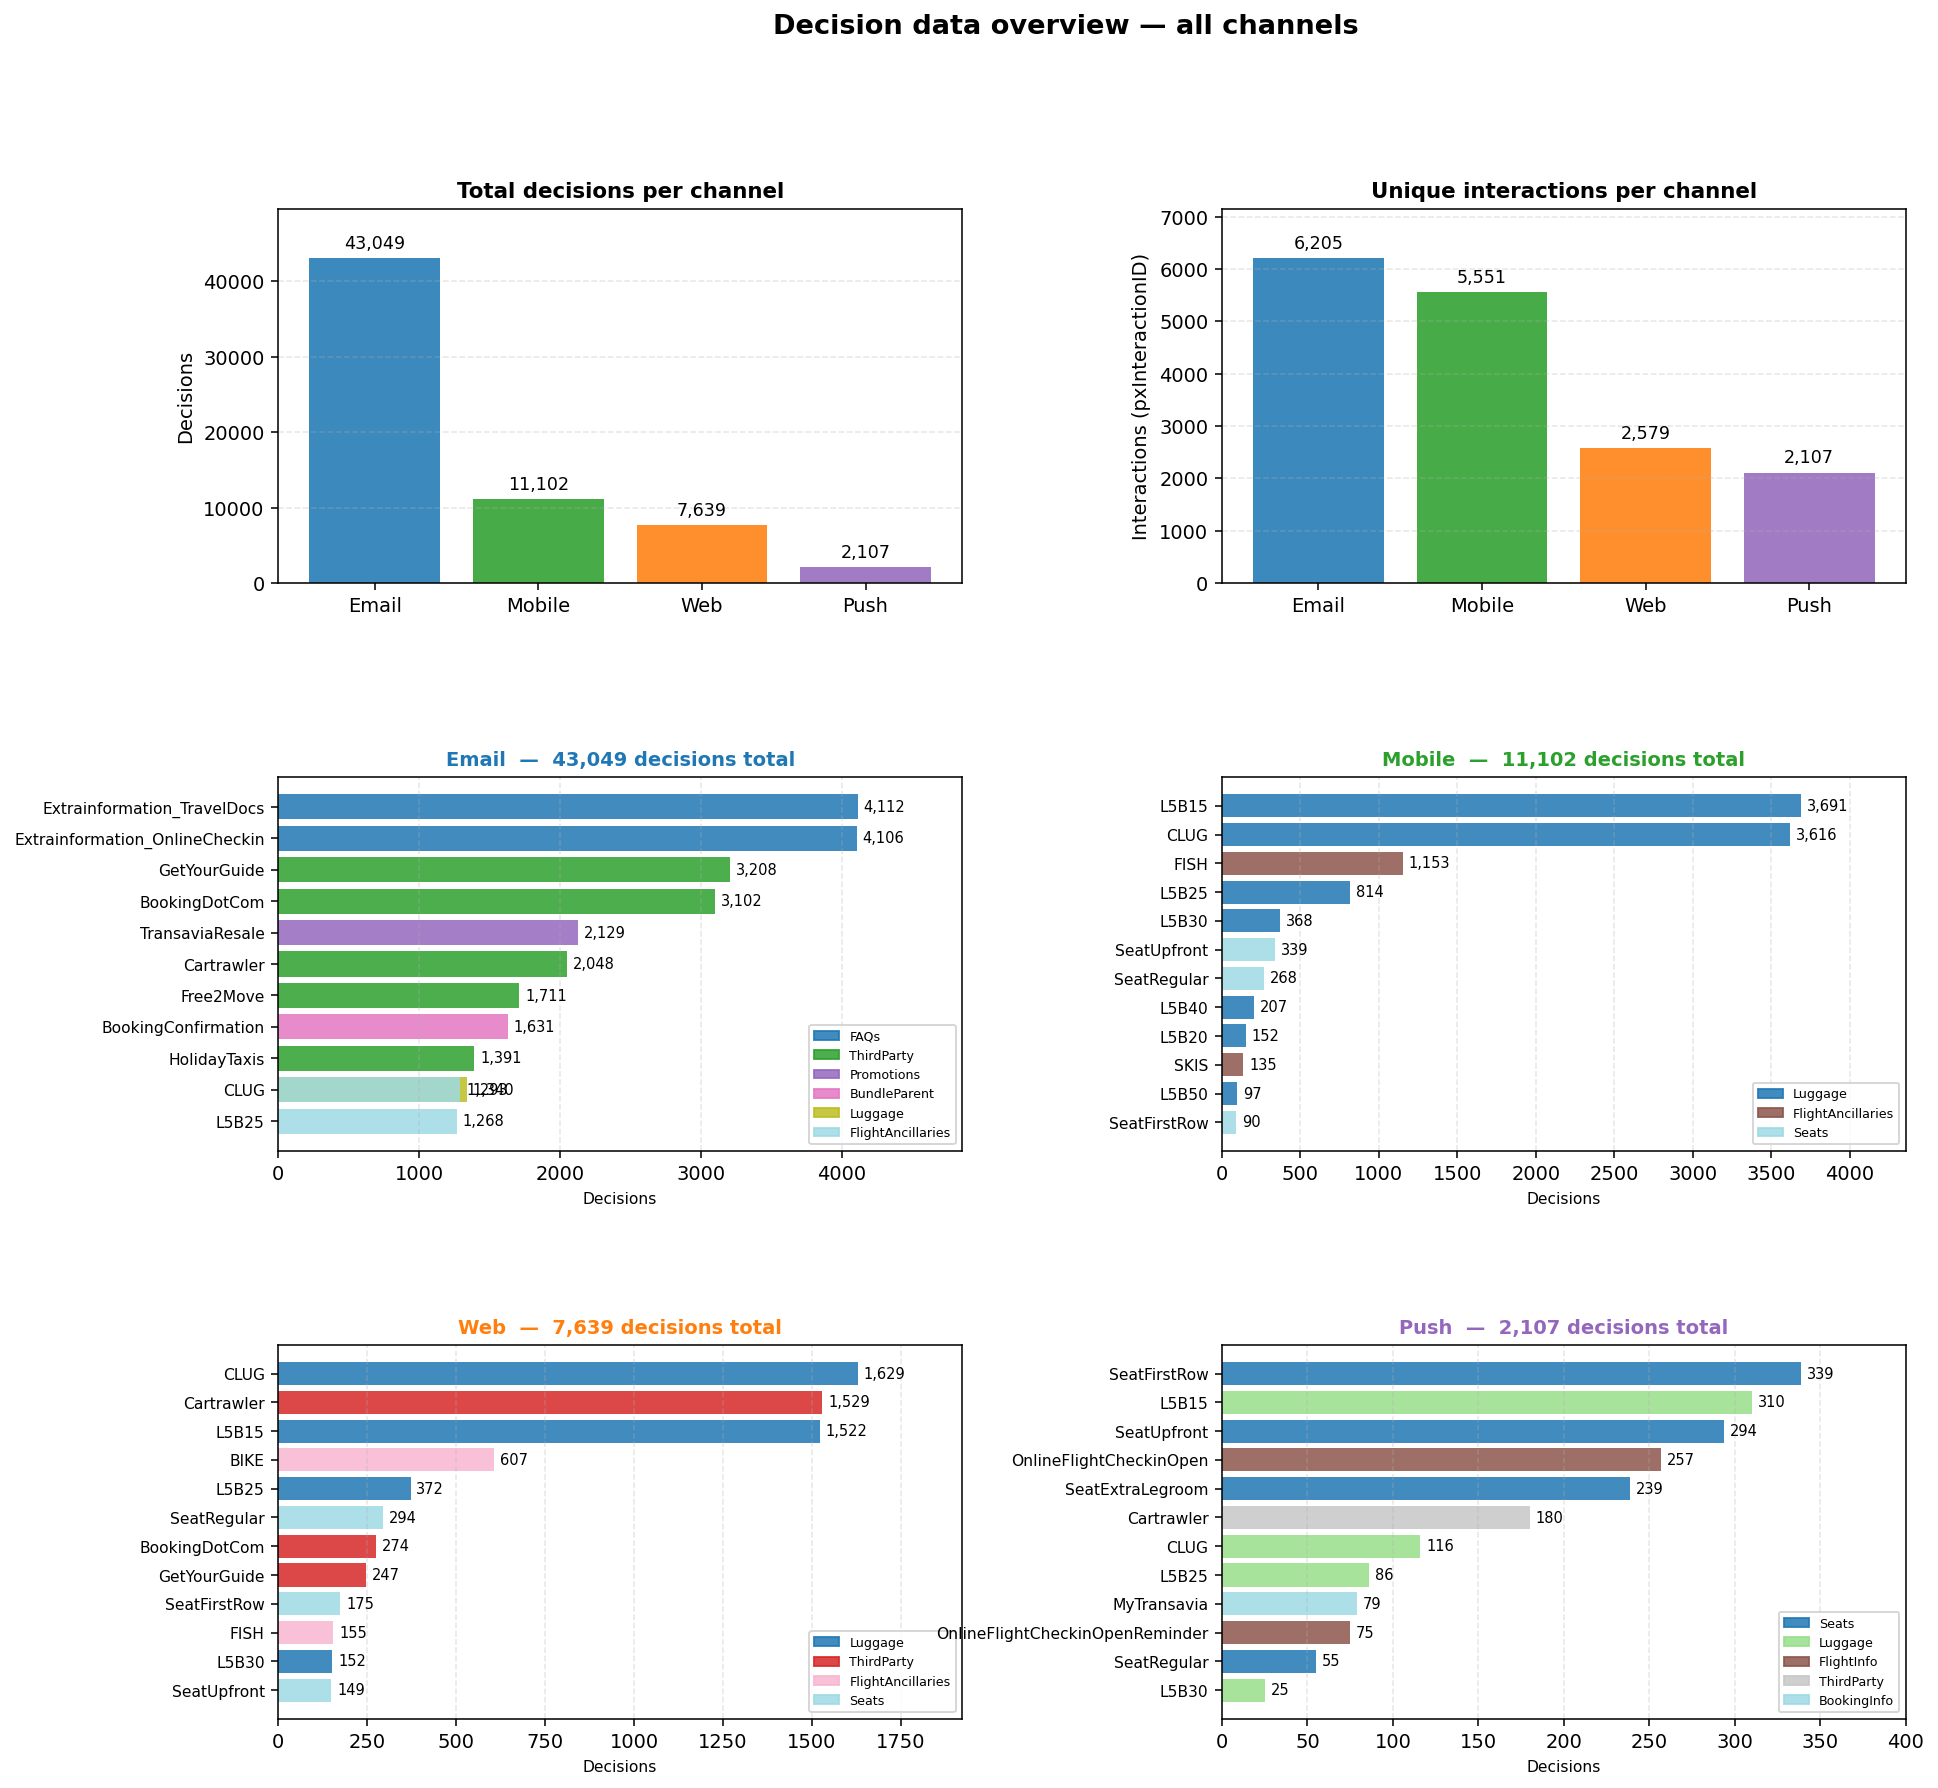

In [1]:
import matplotlib.gridspec as gridspec

CH_COLORS = {'Email': '#1f77b4', 'Mobile': '#2ca02c', 'Web': '#ff7f0e', 'Push': '#9467bd'}
GROUP_CMAP = plt.cm.tab20

rows_ch = []
for filepath in sorted(DECISIONS_DIR.glob("*.json")):
    with open(filepath, encoding="utf-8") as _f:
        for line in _f:
            line = line.strip()
            if not line: continue
            rec = _json.loads(line)
            for dr in rec.get("pxDecisionResults", []):
                rows_ch.append({
                    "pxInteractionID": rec.get("pxInteractionID"),
                    "pyChannel":   dr.get("pyChannel"),
                    "pyDirection": dr.get("pyDirection"),
                    "pyGroup":     dr.get("pyGroup"),
                    "pyIssue":     dr.get("pyIssue"),
                    "pyName":      dr.get("pyName"),
                })

df_ch = pd.DataFrame(rows_ch)

print(f"Total unique interactions: {df_ch['pxInteractionID'].nunique():,}")
print()
print("Decisions per channel / direction:")
print(df_ch.groupby(["pyChannel","pyDirection"]).size()
           .reset_index(name="decisions")
           .sort_values("decisions", ascending=False)
           .to_string(index=False))

fig = plt.figure(figsize=(15, 14))
fig.suptitle("Decision data overview — all channels", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.38)

# Total decisions per channel
ax1 = fig.add_subplot(gs[0, 0])
ch_tot = df_ch.groupby("pyChannel").size().sort_values(ascending=False)
bars = ax1.bar(ch_tot.index, ch_tot.values,
               color=[CH_COLORS.get(c,"#aaa") for c in ch_tot.index], alpha=0.87)
ax1.bar_label(bars, labels=[f"{v:,}" for v in ch_tot.values], padding=3, fontsize=9)
ax1.set_title("Total decisions per channel", fontsize=11, fontweight="bold")
ax1.set_ylabel("Decisions")
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_ylim(0, ch_tot.max() * 1.15)

# Unique interactions per channel
ax2 = fig.add_subplot(gs[0, 1])
int_per_ch = df_ch.groupby("pyChannel")["pxInteractionID"].nunique().sort_values(ascending=False)
bars2 = ax2.bar(int_per_ch.index, int_per_ch.values,
                color=[CH_COLORS.get(c,"#aaa") for c in int_per_ch.index], alpha=0.87)
ax2.bar_label(bars2, labels=[f"{v:,}" for v in int_per_ch.values], padding=3, fontsize=9)
ax2.set_title("Unique interactions per channel", fontsize=11, fontweight="bold")
ax2.set_ylabel("Interactions (pxInteractionID)")
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.set_ylim(0, int_per_ch.max() * 1.15)

# Top offerings per channel
for ch, pos in zip(["Email","Mobile","Web","Push"], [gs[1,0],gs[1,1],gs[2,0],gs[2,1]]):
    ax = fig.add_subplot(pos)
    sub = (df_ch[df_ch["pyChannel"] == ch]
           .groupby(["pyName","pyGroup"]).size()
           .reset_index(name="n")
           .sort_values("n", ascending=False)
           .head(12))
    groups = sub["pyGroup"].unique()
    grp_color = {g: GROUP_CMAP(i / max(len(groups)-1, 1)) for i, g in enumerate(groups)}
    bars = ax.barh(sub["pyName"], sub["n"],
                   color=[grp_color[g] for g in sub["pyGroup"]], alpha=0.85)
    ax.bar_label(bars, labels=[f"{v:,}" for v in sub["n"]], padding=3, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_title(f"{ch}  —  {df_ch[df_ch['pyChannel']==ch].shape[0]:,} decisions total",
                 fontsize=10, fontweight="bold", color=CH_COLORS.get(ch,"#333"))
    ax.set_xlabel("Decisions", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_xlim(0, sub["n"].max() * 1.18)
    handles = [plt.Rectangle((0,0),1,1, color=grp_color[g], alpha=0.85) for g in groups]
    ax.legend(handles, groups, fontsize=6.5, loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.savefig("../data/channel_overview.png", dpi=140, bbox_inches="tight")
plt.show()

### Key observations

**Scale**
The export contains **16,184 unique customer interactions** resulting in **63,897 individual decisions** — meaning Pega scores roughly 4 offerings per interaction on average, though this varies significantly by channel.

**Email (43,049 decisions — 6,205 interactions)**
The largest channel by far, with ~7 offerings scored per interaction. The content mix is broad: FAQs and informational items (TravelDocs, OnlineCheckin) dominate the top, followed by ThirdParty cross-sells (Cartrawler, GetYourGuide, Booking.com). Luggage add-ons are present but are a smaller slice of the total — the email channel is clearly used for a wide range of customer communications beyond ancillary sales.

**Mobile (11,102 decisions — 5,551 interactions)**
Almost exclusively Luggage. CLUG and L5B15 account for the vast majority of decisions, with other ancillaries (FISH, BIKE, seats) making up a small tail. With ~2 offerings per interaction, Mobile is the most focused channel — customers in-app are shown a tight luggage upsell.

**Web (7,639 decisions — 2,579 interactions)**
Similar profile to Mobile but with a slightly broader mix — Luggage still leads (CLUG, L5B15, L5B25) alongside ThirdParty offers like Cartrawler and GetYourGuide. ~3 offerings per interaction.

**Push (2,107 decisions — 2,107 interactions)**
The smallest channel and the most targeted: exactly 1 decision per interaction, confirming Push is a single-nudge mechanism. Content is almost entirely Seats (SeatFirstRow, SeatUpfront, SeatExtraLegroom), making Push a dedicated seat upgrade channel.

---
> **Note on outcomes:** `pyOutcome` is blank for all records in this export. The data captures Pega's *scoring decisions* (what was offered and at what propensity), not whether the customer actually purchased. Ground-truth conversion labels would need to be joined in separately from a booking/transaction system.

In [ ]:
# ── Load raw decision results for outcome + offering counts ──────────────
import json as _json
from pathlib import Path

DECISIONS_DIR = Path("../data/decisions")

rows_dr = []
for filepath in sorted(DECISIONS_DIR.glob("*.json")):
    with open(filepath, encoding="utf-8") as _f:
        for line in _f:
            line = line.strip()
            if not line: continue
            rec = _json.loads(line)
            for dr in rec.get("pxDecisionResults", []):
                rows_dr.append({
                    "pyName":    dr.get("pyName"),
                    "pyIssue":   dr.get("pyIssue"),
                    "pyGroup":   dr.get("pyGroup"),
                    "pyChannel": dr.get("pyChannel"),
                    "pyOutcome": dr.get("pyOutcome"),
                })

df_dr = pd.DataFrame(rows_dr)
sales = df_dr[df_dr["pyIssue"] == "Sales"].copy()

# ── Outcome availability ──────────────────────────────────────────────────
print("pyOutcome values (Sales):")
print(sales["pyOutcome"].fillna("(null)").replace("", "(empty)").value_counts().to_string())
print()
print("⚠  No purchase outcomes recorded — pyOutcome is blank for all records.")
print("   This export contains propensity scores only, not ground-truth conversions.")

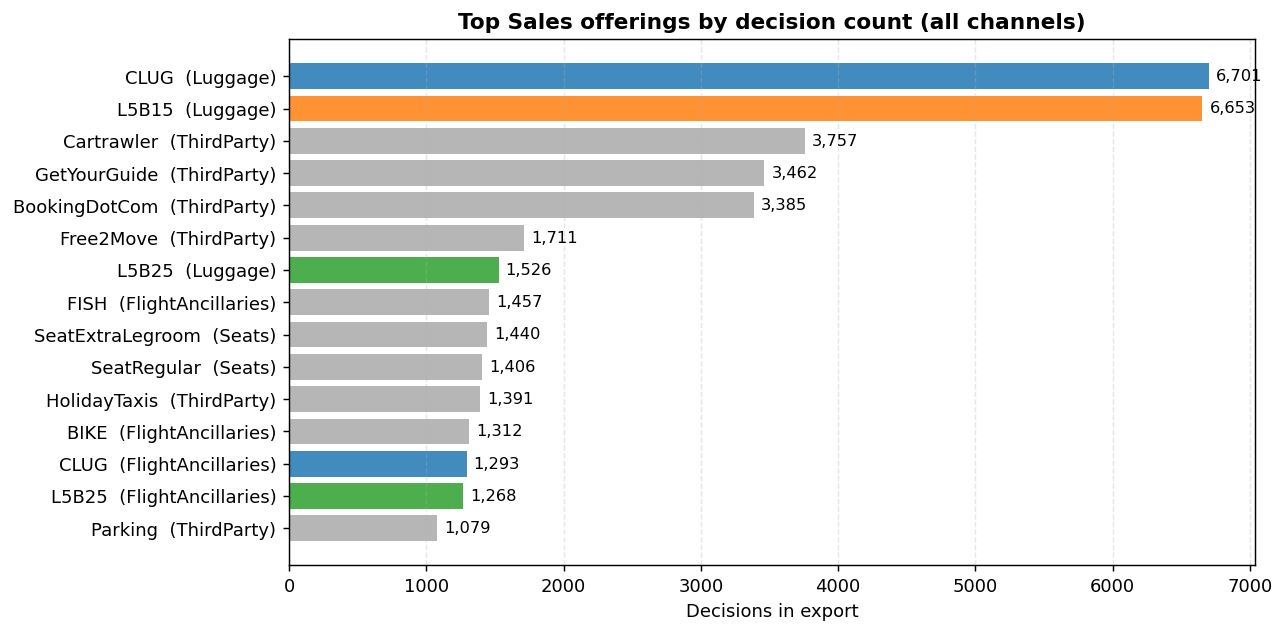

In [1]:
# ── Top offerings by decision count ──────────────────────────────────────
top = (sales.groupby(["pyName", "pyGroup"])
            .size()
            .reset_index(name="decisions")
            .sort_values("decisions", ascending=False)
            .head(15))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top["pyName"] + "  (" + top["pyGroup"] + ")",
    top["decisions"],
    color=[COLORS.get(n, "#aaa") for n in top["pyName"]],
    alpha=0.85,
)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in top["decisions"]], padding=4, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Decisions in export")
ax.set_title("Top Sales offerings by decision count (all channels)", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("../data/top_offerings.png", dpi=130, bbox_inches="tight")
plt.show()

### ThirdParty offerings

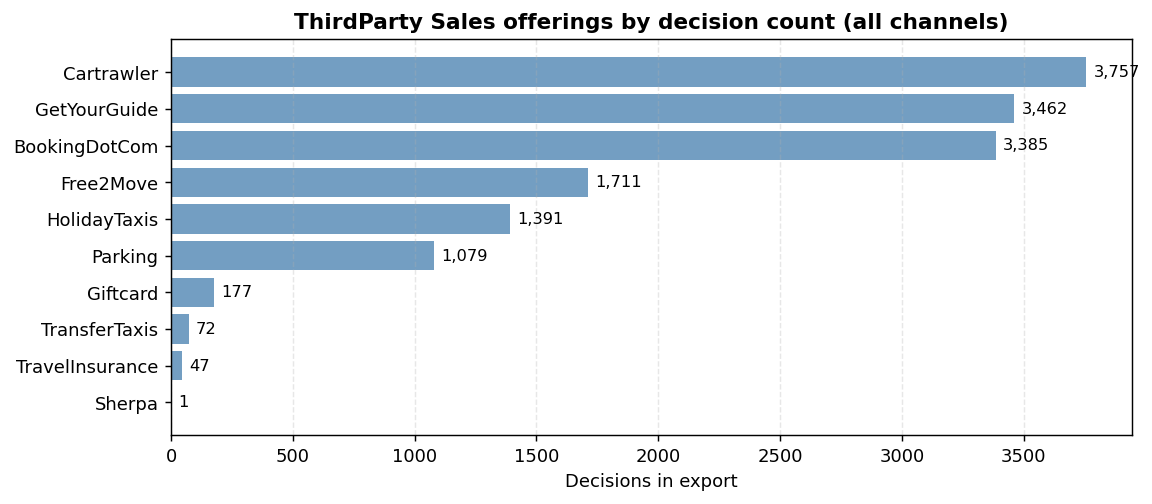

In [1]:
tp = (sales[sales["pyGroup"] == "ThirdParty"]
      .groupby("pyName").size()
      .reset_index(name="decisions")
      .sort_values("decisions", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(tp["pyName"], tp["decisions"], color="#5b8db8", alpha=0.85)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in tp["decisions"]], padding=4, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Decisions in export")
ax.set_title("ThirdParty Sales offerings by decision count (all channels)", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("../data/top_offerings_thirdparty.png", dpi=130, bbox_inches="tight")
plt.show()